# Setup

In [43]:

import matplotlib.pyplot as plt
import numpy as np
from hnn_core import (
    JoblibBackend,
    jones_2009_model,
    simulate_dipole,
)
from hnn_core.network_models import add_erp_drives_to_jones_model
from IPython.core.getipython import get_ipython
from matplotlib.lines import Line2D


## Simulation

In [44]:

net = jones_2009_model()
add_erp_drives_to_jones_model(net)

n_trials = 1

if "dpls" not in locals():
    with JoblibBackend(8):
        dpls = simulate_dipole(
            net,
            tstop=170.0,
            n_trials=n_trials,
        )


## Plot parameters

In [45]:
# defaults extracted from params_default.py for L5Pyr, but can be grabbed from
# net._params

cell_type = "L5_pyramidal"
default_cell_searchkey = net.cell_types[cell_type]["cell_object"].name
celltype_sections = list(
    net.cell_types["L5_pyramidal"]["cell_object"].sections.keys(),
)

# reduce _params down to current cell_type only
default_cell_keymatches = [
    key
    for key in list(net._params.keys())
    if default_cell_searchkey in key
]

defaults = {
    key: value for key, value in net._params.items() if key in default_cell_keymatches
}

# endpoints grabbed from procedurally-generated cell
procedural_end_pts = {}
for section in celltype_sections:
    procedural_end_pts[section] = (
        net.cell_types[cell_type]["cell_object"].sections[section].end_pts
    )

# values pulled directly from _cell_L5Pyr in cells_default
end_pts = {
    "soma": [[0, 0, 0], [0, 0, 23]],
    "apical_trunk": [[0, 0, 23], [0, 0, 83]],
    "apical_oblique": [[0, 0, 83], [-150, 0, 83]],
    "apical_1": [[0, 0, 83], [0, 0, 483]],
    "apical_2": [[0, 0, 483], [0, 0, 883]],
    "apical_tuft": [[0, 0, 883], [0, 0, 1133]],
    "basal_1": [[0, 0, 0], [0, 0, -50]],
    "basal_2": [[0, 0, -50], [-106, 0, -156]],
    "basal_3": [[0, 0, -50], [106, 0, -156]],
}

distinct_colors = {
    "soma": "orange",
    "apical_trunk": "red",
    "apical_oblique": "purple",
    "apical_1": "magenta",
    "apical_2": "pink",
    "apical_tuft": "brown",
    "basal_1": "yellow",
    "basal_2": "olive",
    "basal_3": "darkgreen",
}

blues = {
    "soma": "#4895ef",
    "apical_trunk": "#4cc9f0",
    "apical_oblique": "#caf0f8",
    "apical_1": "#90e0ef",
    "apical_2": "#ade8f4",
    "apical_tuft": "#e0f7fa",
    "basal_1": "#4cc9f0",
    "basal_2": "#90e0ef",
    "basal_3": "#ade8f4",
}

# 3D Plot

In [ ]:
def extract_diameters(
    section_names,
    cell_params,
):
    """
    helper to map section names to their corresponding diameters from
    params_default.py
    """
    extracted = {}
    for name in section_names:
        # adjust the section names to match the default keys
        search_key = name.replace("_", "").lower()

        # look for a key in defaults that contains search_key and "diam"
        found = False

        for cell_param, cell_val in cell_params.items():
            clean_cell_param = cell_param.lower()

            if search_key in clean_cell_param and "diam" in clean_cell_param:
                extracted[name] = cell_val
                found = True
                break

        if not found:
            raise KeyError(
                f"Could not find diameter for section '{name}' in cell_params"
            )

    return extracted



def calculate_neuron_geometry(
    end_pts,
    gap=0,
    x_offsets=None,
):
    """
    calculate the 3D geometry
    """
    # handle horizontal offsets
    x_offs = (
        x_offsets  # noqa: E203,W503
        if x_offsets
        else {
            k: 0
            for k in end_pts.keys()  # noqa: E203,W503
        }
    )
    z_shift = {k: 0 for k in end_pts.keys()}

    # handle vertical offsets ("gap")

    # sort sections by how close they are to soma
    # determine the order in which vertical gaps are processed, since the gaps need
    # to be accumulated as you move away from the soma towards the ends of the
    # dendrites. E.g.:
    # - "soma" is the parent of "apical_trunk", which is the parent of "apical_1" ...
    sorted_sections = sorted(
        # sections
        end_pts.keys(),
        # absolute value of distance from soma on the Z axis
        key=lambda x: abs(end_pts[x][0][2]),
    )

    for child_section in sorted_sections:
        child_section_start = end_pts[child_section][0]

        # set shift for basal_1, which shoud move in the negative direction along
        # the z axis
        if child_section != "soma" and child_section_start == end_pts["soma"][0]:
            # the vertical offset for basal 2/3 should be negative
            z_shift[child_section] = -gap

        # as we move out from the soma, inherit the gap from the parent section
        for parent_section in end_pts.keys():
            parent_section_end = end_pts[parent_section][1]
            if child_section_start == parent_section_end:
                # for apical_oblique, inherit the parent_section shift, but add 0 gap
                # this keeps it in line with apical_trunk, while allowing apical_1
                # to move higher
                if "oblique" in child_section:
                    z_shift[child_section] = z_shift[parent_section]
                else:
                    current_gap = -gap if "basal" in child_section else gap
                    z_shift[child_section] = z_shift[parent_section] + current_gap
                break

    shifted_coords = {}
    for section, coords in end_pts.items():
        dx = x_offs.get(section, 0)
        dz = z_shift.get(section, 0)
        shifted_coords[section] = {
            "x": [coords[0][0] + dx, coords[1][0] + dx],
            "y": [coords[0][1], coords[1][1]],
            "z": [coords[0][2] + dz, coords[1][2] + dz],
        }

    return shifted_coords


def draw_neuron_on_axis(
    ax,
    shifted_coords,
    diameters,
    colors=None,
    width_scale=1.0,
):
    """
    helper to render the neuron from plot_flat_neuron onto a specific axis
    """
    # use normalized diameter to set line width for sections
    diam_values = list(diameters.values())
    d_min, d_max = min(diam_values), max(diam_values)

    # map section diameters to matplotlib line widths
    # scale based on width_scale parameter
    def diam_to_width(d):
        if d_max > d_min:
            # first, normalize diameters into a fixed range [1, 15]
            # - this range is arbitrary based on what looks reasonable in matplotlib
            base_width = 1 + (d - d_min) / (d_max - d_min) * 14
            # second, apply width_scale multiplier
            scaled = base_width * width_scale
            return scaled
        # fallback line width of 5 times the scales
        return 5 * width_scale

    # plot geometry
    for name, coords in shifted_coords.items():
        width = diam_to_width(
            diameters[name],
        )
        color = colors.get(name, "b") if colors else "b"

        # "butt" capstyle ensures sections to not overlab
        ax.plot(
            coords["x"],
            coords["z"],
            color=color,
            linewidth=width,
            solid_capstyle="butt",
        )
def draw_neuron_3d(
    ax,
    shifted_coords,
    diameters,
    colors=None,
    width_scale=1.0,
    shade=True,
):
    """
    draw the neuron in 3D using smoothed cylindrical surfaces
    """
    # number of "planes" used to form each cylinder
    # increase for a smoother object
    resolution = 25

    # iterate through segments
    for name, coords in shifted_coords.items():
        # define start and end vectors for the current segment
        start_pt = np.array(
            [
                coords["x"][0],
                coords["y"][0],
                coords["z"][0],
            ]
        )
        end_pt = np.array(
            [
                coords["x"][1],
                coords["y"][1],
                coords["z"][1],
            ]
        )

        # get the segment vector (directional) and its length (magnitude only)
        branch_vec = end_pt - start_pt
        length = np.linalg.norm(branch_vec)

        # failsafe to skip segments with no length
        if length == 0:
            continue

        # get the cylinder radius
        radius = (diameters[name] / 2.0) * width_scale

        # define the cylinder's longitudinal profile (z) and its thickness (r)
        #  - for z_steps, we start at the base, then stay at base for drawing the
        #    "cap", we move to length, then stay at the length for drawing the "cap"
        #  - for r_steps, we start at center, then expand to radius, we stay at radius
        #    while we move to length, then return to the center to create the cap
        z_steps = np.array([0, 0, length, length])
        r_steps = np.array([0, radius, radius, 0])

        # get the angles around the circle for rotation (i.e., 0 to 360 degrees)
        theta = np.linspace(0, 2 * np.pi, resolution)

        # generate coordinates for the cylinder circumference
        theta_grid, z_idx = np.meshgrid(theta, np.arange(len(z_steps)))

        # store the radius for every point on the cylinder surface
        r_grid = r_steps[z_idx]

        # transform r_grid into 3D coordinates
        x_circle = r_grid * np.cos(theta_grid)
        y_circle = r_grid * np.sin(theta_grid)

        # store the height for every point on the cylinder surface
        # does not requite 3D coordinates
        z_grid = z_steps[z_idx]

        # we need to normalize the segment vector by dividing it by its own length
        # this gives us the "pure" direction, which we will use to build our rotation
        # vectors (side_vec and up_vec)
        # if we used the un-normalized vector, the rotation math would scale the
        # cylinder's thickness or stretch the mesh in weird ways
        direction = branch_vec / length

        # rotate and translate the cylinder to match the segment vector
        if np.allclose(direction, [0, 0, 1]) or np.allclose(direction, [0, 0, -1]):
            # handle segments already aligned with the z-axis where no rotation
            # is needed
            x_final = start_pt[0] + x_circle
            y_final = start_pt[1] + y_circle
            z_final = start_pt[2] + (z_grid if direction[2] > 0 else -z_grid)
        else:
            # when rotation is needed, find a "side" vector perpendicular to the branch
            ref_vec = (
                np.array([1, 0, 0]) if abs(direction[0]) < 0.9 else np.array([0, 1, 0])
            )
            side_vec = np.cross(ref_vec, direction)
            side_vec /= np.linalg.norm(side_vec)

            # find an "up" vector perpendicular to both the branch and the side
            up_vec = np.cross(direction, side_vec)

            # transform raw coordinates into the new 3D basis oriented from the
            # start_pt toward the end_pt
            x_final = (
                start_pt[0]
                + direction[0] * z_grid
                + side_vec[0] * x_circle
                + up_vec[0] * y_circle
            )
            y_final = (
                start_pt[1]
                + direction[1] * z_grid
                + side_vec[1] * x_circle
                + up_vec[1] * y_circle
            )
            z_final = (
                start_pt[2]
                + direction[2] * z_grid
                + side_vec[2] * x_circle
                + up_vec[2] * y_circle
            )

        color = colors.get(name, "b") if colors else "b"
        ax.plot_surface(
            x_final,
            y_final,
            z_final,
            color=color,
            linewidth=0,
            antialiased=False,
            shade=shade,
            alpha=1.0,
        )


def plot_3d_neuron(
    end_pts,
    defaults,
    x_offsets=None,
    gap=0,
    colors=None,
    shade=True,
    figsize=(10, 10),
    width_scale=1.0,
    ax=None,
    show_labels=True,
    show_section_labels=False,
):
    diameters = extract_diameters(
        end_pts.keys(),
        defaults,
    )

    coords = calculate_neuron_geometry(
        end_pts=end_pts,
        gap=gap,
        x_offsets=x_offsets,
    )

    if ax is None:
        fig = plt.figure(
            figsize=figsize,
        )
        ax = fig.add_subplot(
            111,
            projection="3d",
        )

    draw_neuron_3d(
        ax=ax,
        shifted_coords=coords,
        diameters=diameters,
        colors=colors,
        width_scale=10.0,#width_scale=10.0,
        shade=shade,
    )

    # handle legend / labels
    legend_elements = []
    for name, seg_coords in coords.items():
        color = (
            colors.get(
                name,
                "b",
            )
            if colors
            else "b"
        )

        # optionally add section labels in the 3D space
        if show_section_labels:
            ax.text(
                seg_coords["x"][1],
                seg_coords["y"][1],
                seg_coords["z"][1],
                name,
                fontsize=8,
            )

        if colors and name in colors:
            legend_elements.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=name,
                ),
            )

    # force equal axis scaling to prevent neurons from looking stretched
    # ------------------------------
    # matplotlib stretches whatever ranges we give it to fill a square area in 3d
    # space. so we need to ensure that the "span" is the same for each axis,
    # otherwise axes may be stretched to fill the cube, distorting the shapes

    # get the ranges
    x_lim = ax.get_xlim3d()
    y_lim = ax.get_ylim3d()
    z_lim = ax.get_zlim3d()

    # get the widest range, divide by two since we'll center around the midpoint
    half_max_range = (
        max(
            np.diff(x_lim),
            np.diff(y_lim),
            np.diff(z_lim),
        )[0]
        / 2.0
    )

    # get the midpoint for each range for centering
    mid_x = np.median(x_lim)
    mid_y = np.median(y_lim)
    mid_z = np.median(z_lim)

    # center around the midpoint using half of the maximum range
    ax.set_xlim3d(mid_x - half_max_range, mid_x + half_max_range)
    ax.set_ylim3d(mid_y - half_max_range, mid_y + half_max_range)
    ax.set_zlim3d(mid_z - half_max_range, mid_z + half_max_range)

    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_zlabel("z (µm)")
    ax.set_box_aspect((1, 1, 1))

    # adjust style of the grid
    ax.xaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.yaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.zaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)

    if colors and show_labels:
        unique_handles = []
        seen = set()
        for h in legend_elements:
            if h.get_label() not in seen:
                unique_handles.append(h)
                seen.add(h.get_label())
        ax.legend(
            handles=unique_handles,
            loc="upper left",
            fontsize=8,
        )

    return ax



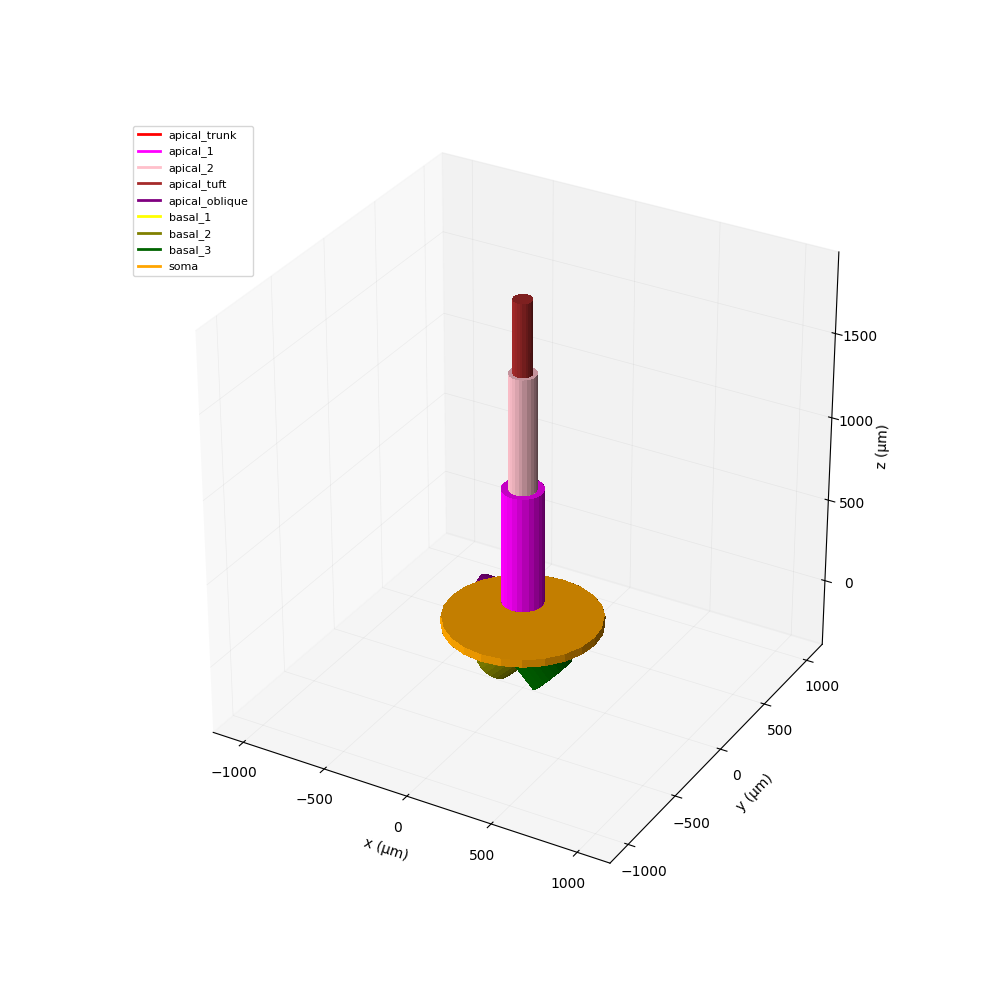

In [47]:
get_ipython().run_line_magic("matplotlib", "widget")

add_gap = False

if add_gap:
    gap = 20
    x_offsets = {
        "apical_oblique": -20,
        "apical_1": 0,
        "apical_2": 0,
        "apical_tuft": 0,
        "basal_2": -20,
        "basal_3": 20,
    }
else:
    gap = 0
    x_offsets = {
        "apical_oblique": 0,
        "apical_1": 0,
        "apical_2": 0,
        "apical_tuft": 0,
        "basal_2": 0,
        "basal_3": 0,
    }

ax_main = plot_3d_neuron(
    procedural_end_pts,
    defaults,
    x_offsets=x_offsets,
    gap=gap,
    colors=distinct_colors,
    shade=True,
    width_scale=2,
    show_section_labels=False,
)

plt.show()

In [51]:
import bpy
def generate_blender_neuron(
    end_pts,
    defaults,
    x_offsets=None,
    gap=0,
    colors=None,
    scale_factor=0.01,
    width_scale=2.0,
):
    """
    """
    diameters = extract_diameters(
        end_pts.keys(),
        defaults,
    )
    shifted_coords = calculate_neuron_geometry(
        end_pts=end_pts,
        gap=gap,
        x_offsets=x_offsets,
    )

    if bpy.context.object and bpy.context.object.mode != "OBJECT":
        bpy.ops.object.mode_set(mode="OBJECT")
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.object.delete()

    for name, coords in shifted_coords.items():
        # raw coordinates
        p0_raw = np.array([coords["x"][0], coords["y"][0], coords["z"][0]])
        p1_raw = np.array([coords["x"][1], coords["y"][1], coords["z"][1]])

        # vectors
        vec_raw = p1_raw - p0_raw
        length_raw = np.linalg.norm(vec_raw)

        # skip iteration when possible divide-by-zero situation occurs
        if length_raw < 1e-6:
            continue

        # get radius with width scaling
        radius_raw = (diameters[name] / 2.0) * width_scale

        # apply global scale_factor for Blender
        p0 = p0_raw * scale_factor
        p1 = p1_raw * scale_factor
        length = length_raw * scale_factor
        radius = radius_raw * scale_factor
        midpoint = (p0 + p1) / 2.0

        bpy.ops.mesh.primitive_cylinder_add(
            radius=radius,
            depth=length,
            location=midpoint,
            end_fill_type="NGON",
        )

        obj = bpy.context.active_object
        obj.name = f"Section_{name}"
        obj.scale = (1.0, 1.0, 1.0)

        # align direction for vectors
        direction = vec_raw / length_raw
        v_orig = np.array([0, 0, 1])
        axis = np.cross(v_orig, direction)
        axis_norm = np.linalg.norm(axis)

        if axis_norm < 1e-6:
            if np.dot(v_orig, direction) < 0:
                obj.rotation_euler = (np.pi, 0, 0)
        else:
            angle = np.arccos(np.clip(np.dot(v_orig, direction), -1.0, 1.0))
            obj.rotation_mode = "AXIS_ANGLE"
            obj.rotation_axis_angle = (
                angle,
                axis[0],
                axis[1],
                axis[2],
            )

        if colors and name in colors:
            mat = bpy.data.materials.get(f"Mat_{name}") or bpy.data.materials.new(
                name=f"Mat_{name}",
            )
            if not obj.data.materials:
                obj.data.materials.append(mat)


generate_blender_neuron(
    end_pts=procedural_end_pts,
    defaults=defaults,
    x_offsets=x_offsets,
    gap=0,
    colors=distinct_colors,
    scale_factor=0.01,
    width_scale=2.0,
)

In [49]:
bpy.ops.export_scene.gltf(
filepath="3D_L5_PN.glb",
export_format="GLB",
use_selection=False, # save every object, not just those selected
)

15:18:19 | INFO: Starting glTF 2.0 export
15:18:19 | INFO: Extracting primitive: Cylinder.036
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.037
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.038
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.039
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.040
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.041
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.042
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.043
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Extracting primitive: Cylinder.044
15:18:19 | INFO: Primitives created: 1
15:18:19 | INFO: Finished glTF 2.0 export in 0.02244424819946289 s



{'FINISHED'}

In [50]:
bpy.ops.wm.save_as_mainfile(filepath="3D_L5_PN_thick.blend")

Info: Saved as "3D_L5_PN_thick.blend"


{'FINISHED'}